In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Task 1
Calculate the mean and standard deviation of Age.  
Compute Z-Score for each value.  
Identify outliers using |Z| > 3 conditions.  
Remove those outliers and show the new dataset length  


In [141]:
age = [18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70]

In [142]:
df = pd.DataFrame({'Age': age})

In [143]:
len(df)

20

In [144]:
df['Z_score'] = (df['Age'] - df['Age'].mean())/df['Age'].std()

In [145]:
outlier = df[abs(df['Z_score'])> 3 ]
outlier

,Age,Z_score
19,70,3.428778


In [146]:
df = df[abs(df['Z_score']) < 3 ]
len(df)

19

#Task 2
Calculate Q1 (25th percentile) and Q3 (75th percentile).  
Find IQR = Q3 - Q1.  
Calculate lower bound and upper bound.  
Identify outliers.  
Cap (clip) the outliers to the bounds instead of deleting them.  
Show min and max after capping.  


In [147]:
salary = [25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]

In [148]:
df = pd.DataFrame({'Salary': salary})

In [149]:
df.head(5)

,Salary
0,25
1,28
2,30
3,32
4,32


In [150]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
print(lower_limit)
print(upper_limit)
outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
outliers

35.0
-17.5
122.5


,Salary
20,120
21,150
22,200
23,250
24,500


In [151]:
df['Salary'] = np.where(df['Salary'] > upper_limit, upper_limit,
                        np.where(df['Salary'] < lower_limit, lower_limit,
                                 df['Salary']))

In [152]:
df.describe()

,Salary
count,25.000000
mean,59.560000
std,34.592364
min,25.000000
25%,35.000000
50%,45.000000
75%,70.000000
max,122.500000


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Salary  25 non-null     float64
dtypes: float64(1)
memory usage: 332.0 bytes


#Task 3
For Dataset A, plot a histogram (conceptually) – is it normal or skewed?  
Which method (Z-Score or IQR) would you choose for Dataset A? Why?  
For Dataset B, which method would you choose? Why?  
Apply IQR on Dataset B and count how many outliers you get.  


In [154]:
exam_score = [55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]
house_price = [30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200]

In [155]:
df_1 = pd.DataFrame({'Exam Score' : exam_score})
df_2 = pd.DataFrame({'House Price': house_price})

<Axes: xlabel='Exam Score', ylabel='Count'>

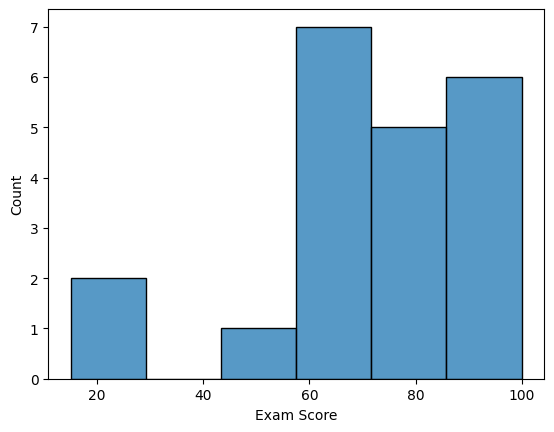

In [156]:
sns.histplot(data = df_1, x = 'Exam Score')

<Axes: xlabel='Exam Score', ylabel='Density'>

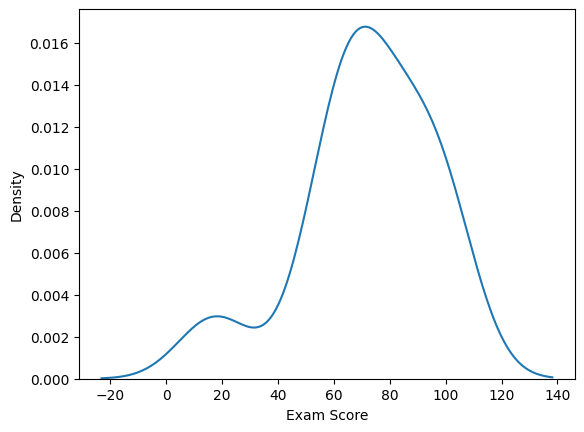

In [157]:
sns.kdeplot(data = df_1, x ='Exam Score')

From the data distribution, it seems that, its not normally distributed, hence it would perform better in IQR method.

<Axes: xlabel='House Price', ylabel='Count'>

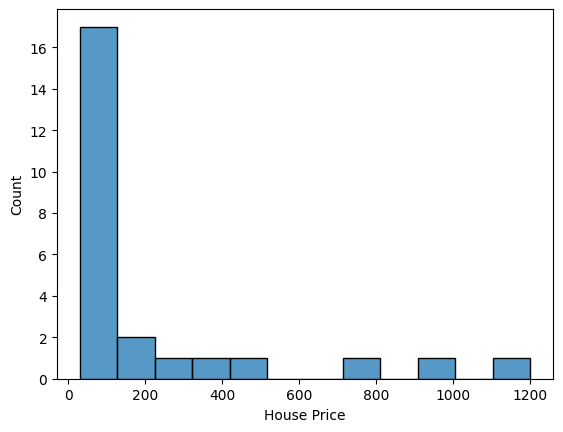

In [158]:
sns.histplot(data = df_2, x = 'House Price')

<Axes: xlabel='House Price', ylabel='Density'>

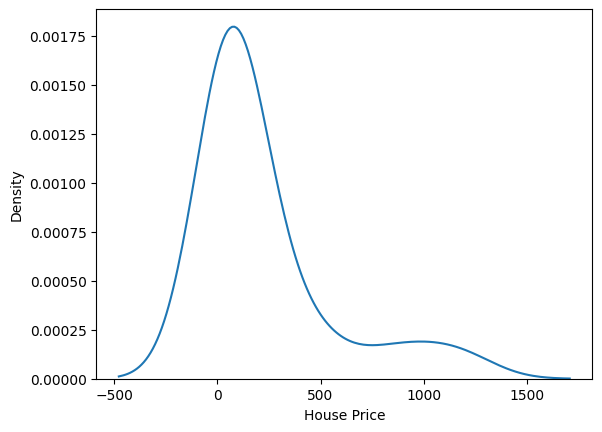

In [159]:
sns.kdeplot(data = df_2, x = 'House Price')

From the data distribution, it seems that, its not normally distributed, hence it would perform better in IQR method.

In [160]:
Q3 = df_2['House Price'].quantile(0.75)
Q1 = df_2['House Price'].quantile(0.25)
iqr = Q3 - Q1
upper_bound = Q3 + 1.5*iqr
lower_bound = Q1 - 1.5*iqr

In [161]:
print(upper_bound)
print(lower_bound)

432.5
-187.5


In [162]:
outliers = df_2[(df_2['House Price'] < lower_bound) | (df_2['House Price'] > upper_bound)]

In [163]:
outliers

,House Price
21,500
22,800
23,1000
24,1200


#Task 4
Dataset (Product ratings out of 10):
[1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]

Tasks:  
Use 5% Winsorization (x = 5, meaning cap at 5th and 95th percentiles).  
Calculate 5th percentile and 95th percentile.  
Cap all values below 5th percentile to the 5th percentile value.
Cap all values above 95th percentile to the 95th percentile value.  
Show the min and max after Winsorization.  
Explain why Winsorization is better than deletion here.  



In [164]:
product = [1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]
df = pd.DataFrame({"Product" : product})

In [165]:
fifth = df['Product'].quantile(0.05)
ninety_five = df['Product'].quantile(0.95)


In [166]:
print(fifth)
print(ninety_five)

1.0
10.0


In [167]:
df['Product'] = np.where(df['Product'] < fifth, fifth,
                         np.where(df['Product'] > ninety_five, ninety_five,
                                  df['Product']))

In [168]:
df['Product'].min()

1.0

In [169]:
df['Product'].max()

10.0

#Task 5
Dataset (Product ratings out of 10):
[12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]


Tasks:  
Plot a histogram (conceptually) and decide if the data is normal or skewed.  
Apply Z-Score method (|Z| > 3) – count outliers and list them.  
Apply IQR method (1.5×IQR) – count outliers and list them.  
Which method found more outliers? Why?  
Which method would you trust here? Justify.  


<Axes: xlabel='Ratings', ylabel='Count'>

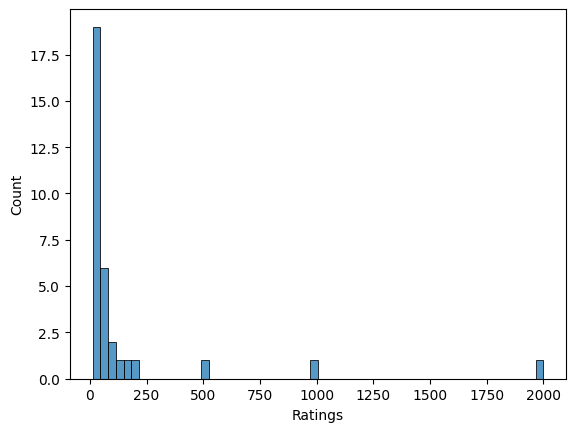

In [170]:
ratings = [12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]
df = pd.DataFrame({"Ratings": ratings})
sns.histplot(df['Ratings'])

<Axes: xlabel='Ratings', ylabel='Density'>

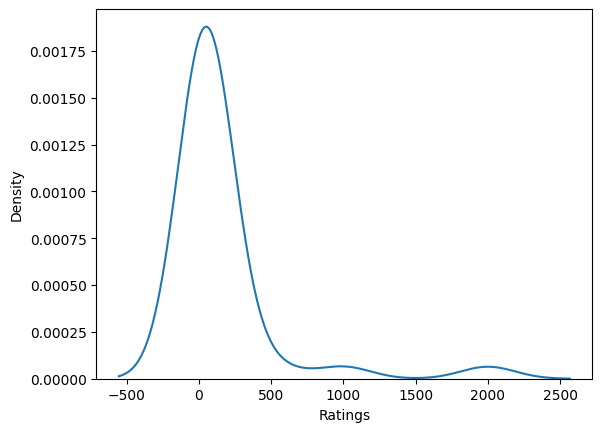

In [171]:
sns.kdeplot(df['Ratings'])

In [172]:
df['Z_score_value'] = (df['Ratings'] - df['Ratings'].mean()) / df['Ratings'].std()

In [173]:
outliers = df[abs(df['Z_score_value']) > 3]

In [174]:
print(len(outliers))

1


In [175]:
outliers

,Ratings,Z_score_value
32,2000,4.865011


In [176]:
q3 = df['Ratings'].quantile(0.75)
q1 = df['Ratings'].quantile(0.25)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
print(lower_bound)
print(upper_bound)

-57.5
162.5


In [177]:
outliers = df[(df['Ratings'] < lower_bound) | (df['Ratings'] > upper_bound)]
print(len(outliers))

4


In [178]:
outliers


,Ratings,Z_score_value
29,200,0.123954
30,500,0.914130
31,1000,2.231090
32,2000,4.865011


I would go with IQR method, as it is dealt with skewed distribution.

Scenario:
A company gives an annual bonus (in thousand BDT). HR wants to remove extreme outliers before calculating average bonus for policy making.  

Dataset (Bonus amounts):
[5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]  


Tasks:  
Calculate mean, median, and mode. What do you observe?  
Apply IQR method and find outliers.  
Instead of deleting, apply Winsorization with x = 3 (i.e., cap at 3rd and 97th percentile).  
Show the new min and max after Winsorization.  
Calculate the new mean after Winsorization. Is it more reasonable than the original mean?  



In [179]:
bonus = [5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]
df = pd.DataFrame({"Bonus" : bonus})

In [180]:
mean = df['Bonus'].mean()
median = df['Bonus'].median()
mode = df['Bonus'].mode()
print(mean)
print(median)
print(mode)


42.24242424242424
12.0
0     7
1     8
2    10
Name: Bonus, dtype: int64


<Axes: xlabel='Bonus', ylabel='Density'>

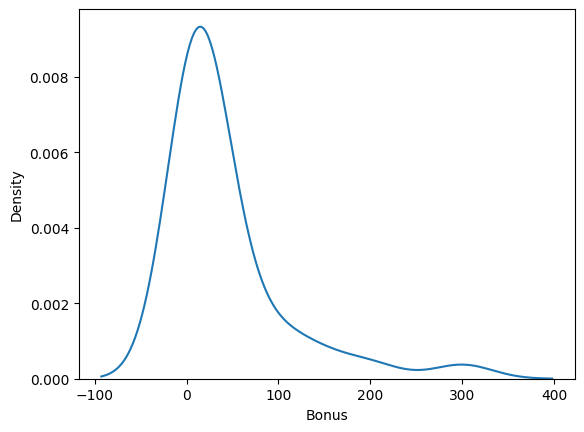

In [181]:
sns.kdeplot(data = df, x = 'Bonus')

In [182]:
q3 = df['Bonus'].quantile(0.75)
q1 = df['Bonus'].quantile(0.25)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
print(lower_bound)
print(upper_bound)

-40.0
88.0


In [183]:
outliers = df[(df['Bonus'] < lower_bound) | (df['Bonus'] > upper_bound)]
print(len(outliers))

5


In [184]:
outliers

,Bonus
28,100
29,120
30,150
31,200
32,300


In [185]:
#Winsorization method

In [186]:
low_percentile = df['Bonus'].quantile(0.03)
high_percentile = df['Bonus'].quantile(0.97)
print(low_percentile)
print(high_percentile)

5.0
203.99999999999991


In [187]:
df['Bonus'] = np.where(df['Bonus'] < low_percentile, low_percentile,
              np.where(df['Bonus'] > high_percentile, high_percentile,
                       df['Bonus']))

In [190]:
df['Bonus'].describe()

,Bonus
count,33.000000
mean,39.333333
std,54.948082
min,5.000000
25%,8.000000
50%,12.000000
75%,40.000000
max,204.000000


In [191]:
df['Bonus'].mean()

np.float64(39.333333333333336)

In [192]:
df['Bonus']

,Bonus
0,5.0
1,5.0
2,6.0
3,6.0
4,7.0
5,7.0
6,7.0
7,8.0
8,8.0
9,8.0
